## Exploring the Challenger Data Set





The dataframe should contain the following columns:
- data: the date of the launch
- count: the number of O-rings
- temp: the temperature at the time of the launch
- pressure: the pressure at the time of the launch
- malfunction: nr of O-rings that malfunctioned

In [1]:
import numpy as np
import pandas as pd


df = pd.read_csv('data.csv')
df

,Date,Count,Temperature,Pressure,Malfunction
0,4/12/81,6,66,50,0
1,11/12/81,6,70,50,1
2,3/22/82,6,69,50,0
3,11/11/82,6,68,50,0
4,4/04/83,6,67,50,0
5,6/18/82,6,72,50,0
6,8/30/83,6,73,100,0
7,11/28/83,6,70,100,0
8,2/03/84,6,57,200,1
9,4/06/84,6,63,200,1


The initial mistake they made is they removed the data where no malfunction was observed. This is a common mistake in data analysis, as it can lead to biased results and incorrect conclusions. By only including data where malfunctions occurred, they were not able to accurately assess the relationship between temperature, pressure, and the likelihood of O-ring malfunctions. This could have led them to underestimate the risks associated with low temperatures and high pressures, which ultimately contributed to the Challenger disaster.

First let's scatter the malfunction count against the temperature and pressure to see if there is a relationship between them. 

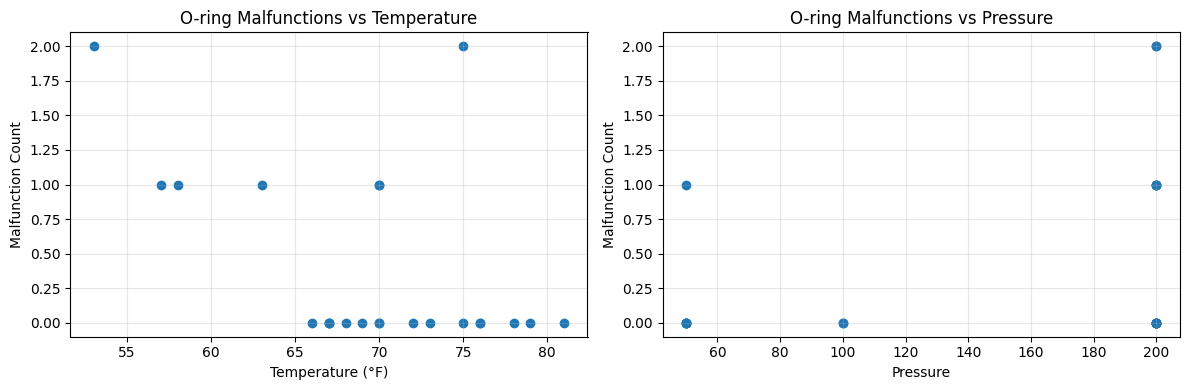

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Malfunction vs Temperature
axes[0].scatter(df['Temperature'], df['Malfunction'])
axes[0].set_xlabel('Temperature (°F)')
axes[0].set_ylabel('Malfunction Count')
axes[0].set_title('O-ring Malfunctions vs Temperature')
axes[0].grid(True, alpha=0.3)

# Malfunction vs Pressure
axes[1].scatter(df['Pressure'], df['Malfunction'])
axes[1].set_xlabel('Pressure')
axes[1].set_ylabel('Malfunction Count')
axes[1].set_title('O-ring Malfunctions vs Pressure')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Pressure and Malfunction count does not seem to show a clear relationship. So not to fall for something like the simson paradox, let's look at the relationship between temperature and malfunction count by only focusing on the data where the pressure is 200psi.

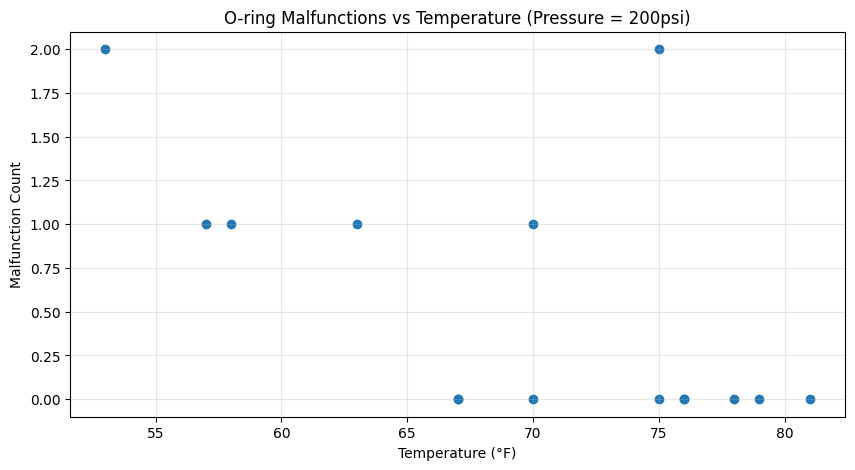

In [3]:
df_200psi = df[df['Pressure'] == 200]

plt.figure(figsize=(10, 5))
plt.scatter(df_200psi['Temperature'], df_200psi['Malfunction'])
plt.xlabel('Temperature (°F)')
plt.ylabel('Malfunction Count')
plt.title('O-ring Malfunctions vs Temperature (Pressure = 200psi)')
plt.grid(True, alpha=0.3)
plt.show()

There seems to be a higher malfunction count at lower temperatures. Let's take a closer look. 
Let's assume that the malfunctions are independent and identically distributed (i.i.d.) Bernoulli random variables, where each O-ring has a probability of malfunctioning that depends on the temperature. We can model this relationship using logistic regression, which is a common method for modeling binary outcomes.

Coefficient: 0.9079
Intercept: 0.8153
Model Score: 0.8000


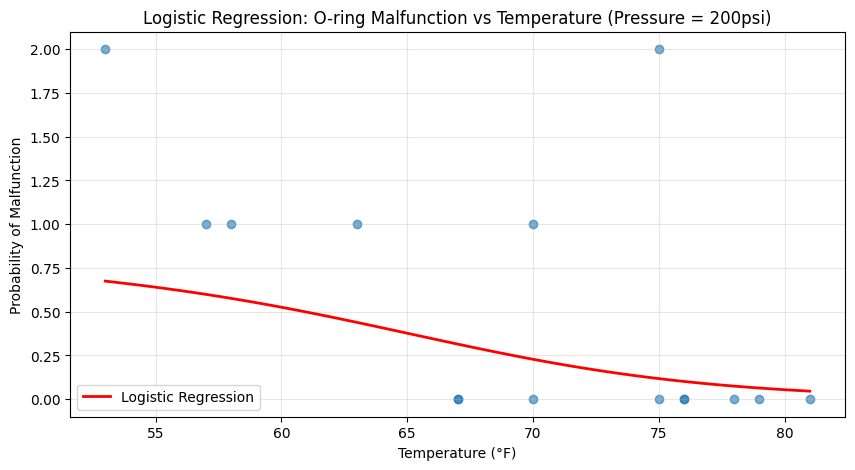

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare data for logistic regression
X = df_200psi[['Temperature']].values
y = df_200psi['Malfunction'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_scaled, y)

print(f"Coefficient: {log_reg.coef_[0][0]:.4f}")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print(f"Model Score: {log_reg.score(X_scaled, y):.4f}")

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
y_pred = log_reg.predict_proba(X_range_scaled)[:, 1]

plt.figure(figsize=(10, 5))
plt.scatter(df_200psi['Temperature'], df_200psi['Malfunction'], alpha=0.6)
plt.plot(X_range, y_pred, 'r-', linewidth=2, label='Logistic Regression')
plt.xlabel('Temperature (°F)')
plt.ylabel('Probability of Malfunction')
plt.title('Logistic Regression: O-ring Malfunction vs Temperature (Pressure = 200psi)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Our Logistic regression model clearly shows that the probability of malfunction increases the colder it gets. This is consistent with the observations from the scatter plot and supports the hypothesis that low temperatures increase the likelihood of O-ring malfunctions.
Now let's use our model to predict the probability of malfunction at the temperature of 31°F (just below 0°C) and a pressure of 200psi, which were the conditions during the Challenger launch.

In [ ]:
log_reg.predict_proba(scaler.transform([[31]]))[:, 1]

array([0.85173425])

### Conclusion
It looks like the probability of malfunction at 31°F is around 0.85.
Based on this we can conclude that the launch was extremely risky.